<a href="https://colab.research.google.com/github/fbnlb/fbnlb/blob/main/Simulaci%C3%B3n_de_ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DE SEÑAL ECG CON STFT Y TRANSFORMADA DE GABOR

1. Generando señal ECG sintética...
   ✓ Duración: 10 segundos
   ✓ Frecuencia de muestreo: 1000 Hz
   ✓ Número de muestras: 10000
   ✓ Frecuencia cardíaca simulada: 72 BPM

2. Aplicando STFT (Short-Time Fourier Transform)...
   ✓ Resolución temporal: 0.0560 s
   ✓ Resolución frecuencial: 3.91 Hz
   ✓ Rango de frecuencias: 0.0 - 500.0 Hz

3. Aplicando Transformada de Gabor...
   Calculando transformada de Gabor para cada frecuencia...
   Progreso: 0/50 frecuencias procesadas
   Progreso: 10/50 frecuencias procesadas
   Progreso: 20/50 frecuencias procesadas
   Progreso: 30/50 frecuencias procesadas
   Progreso: 40/50 frecuencias procesadas
   Completado: 50 frecuencias procesadas
   ✓ Número de frecuencias analizadas: 50
   ✓ Rango de frecuencias: 0.50 - 200.00 Hz

4. Generando visualizaciones...

ANÁLISIS COMPLETADO EXITOSAMENTE

📊 CARACTERÍSTICAS DE LOS ESPECTROGRAMAS:
──────────────────────────────────────────────────
🔹 STFT:
 

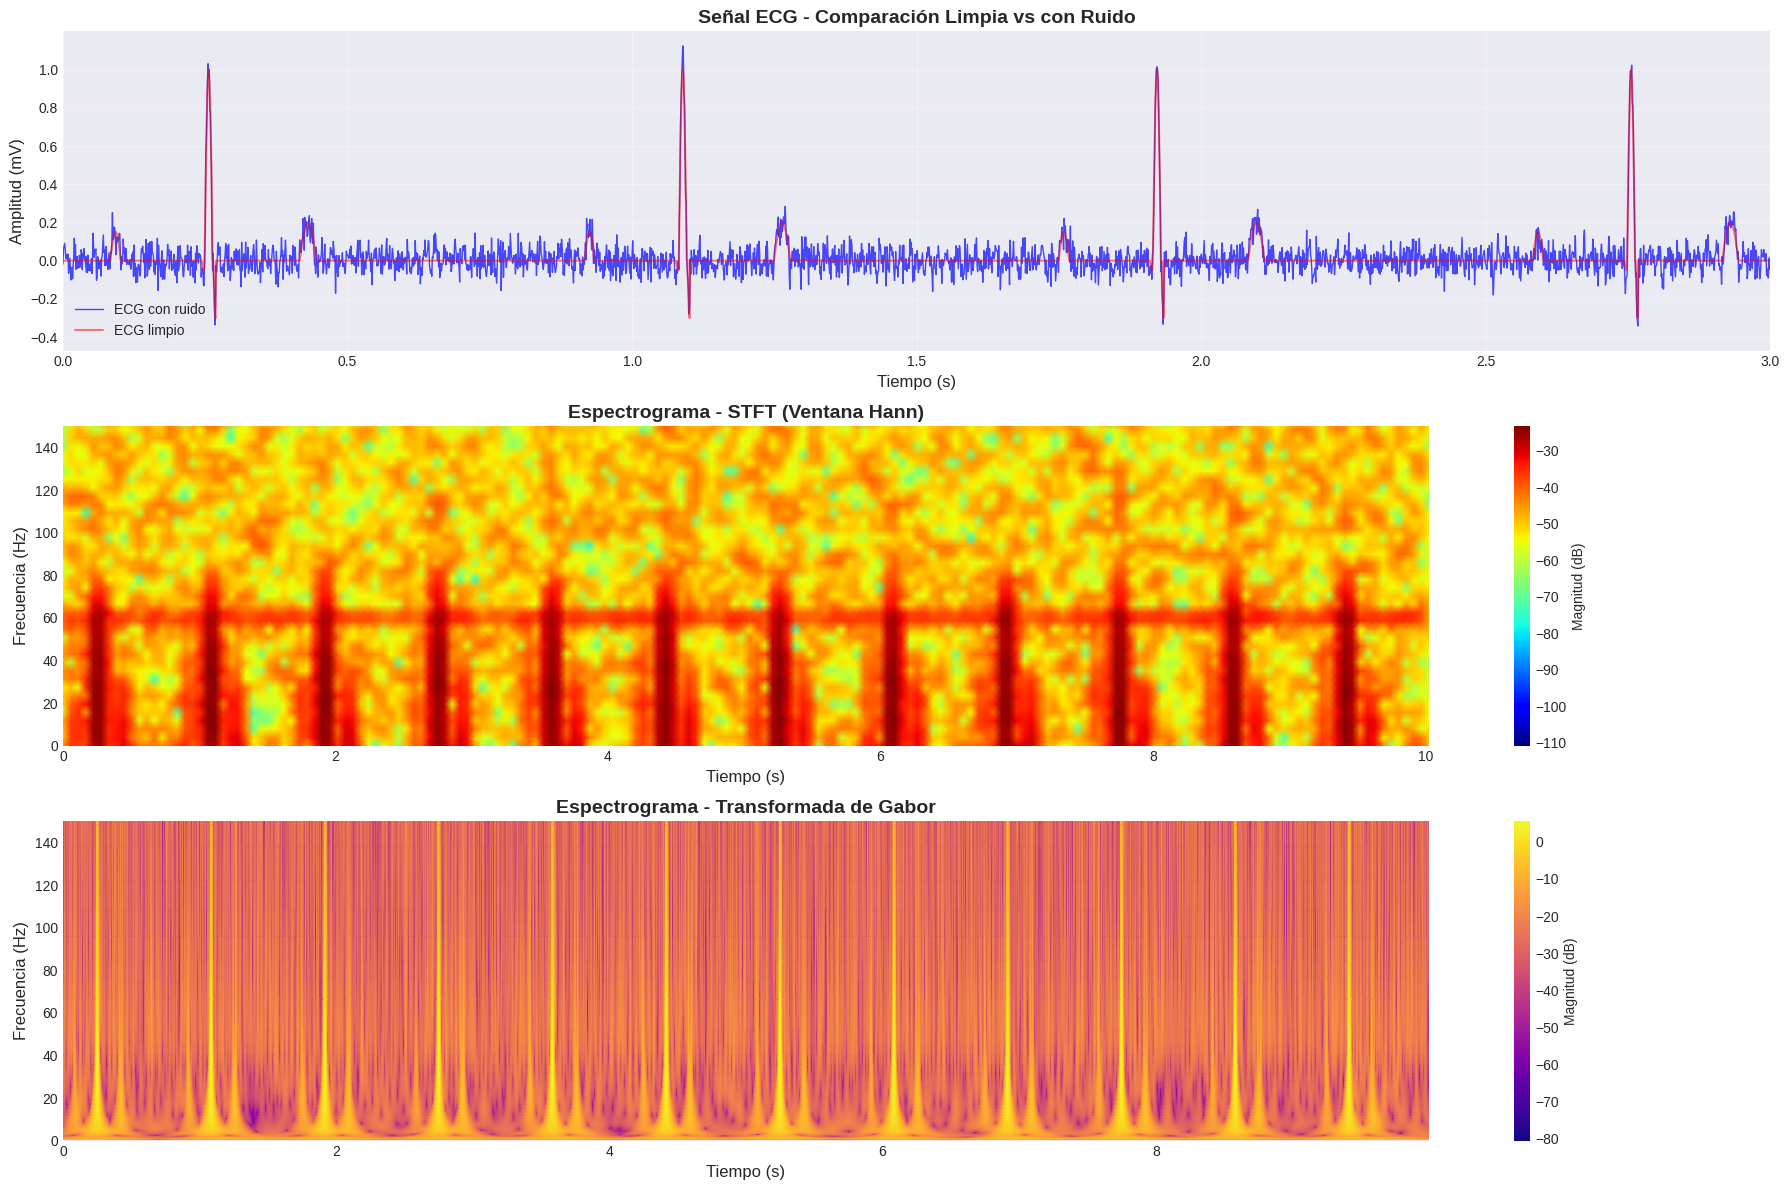

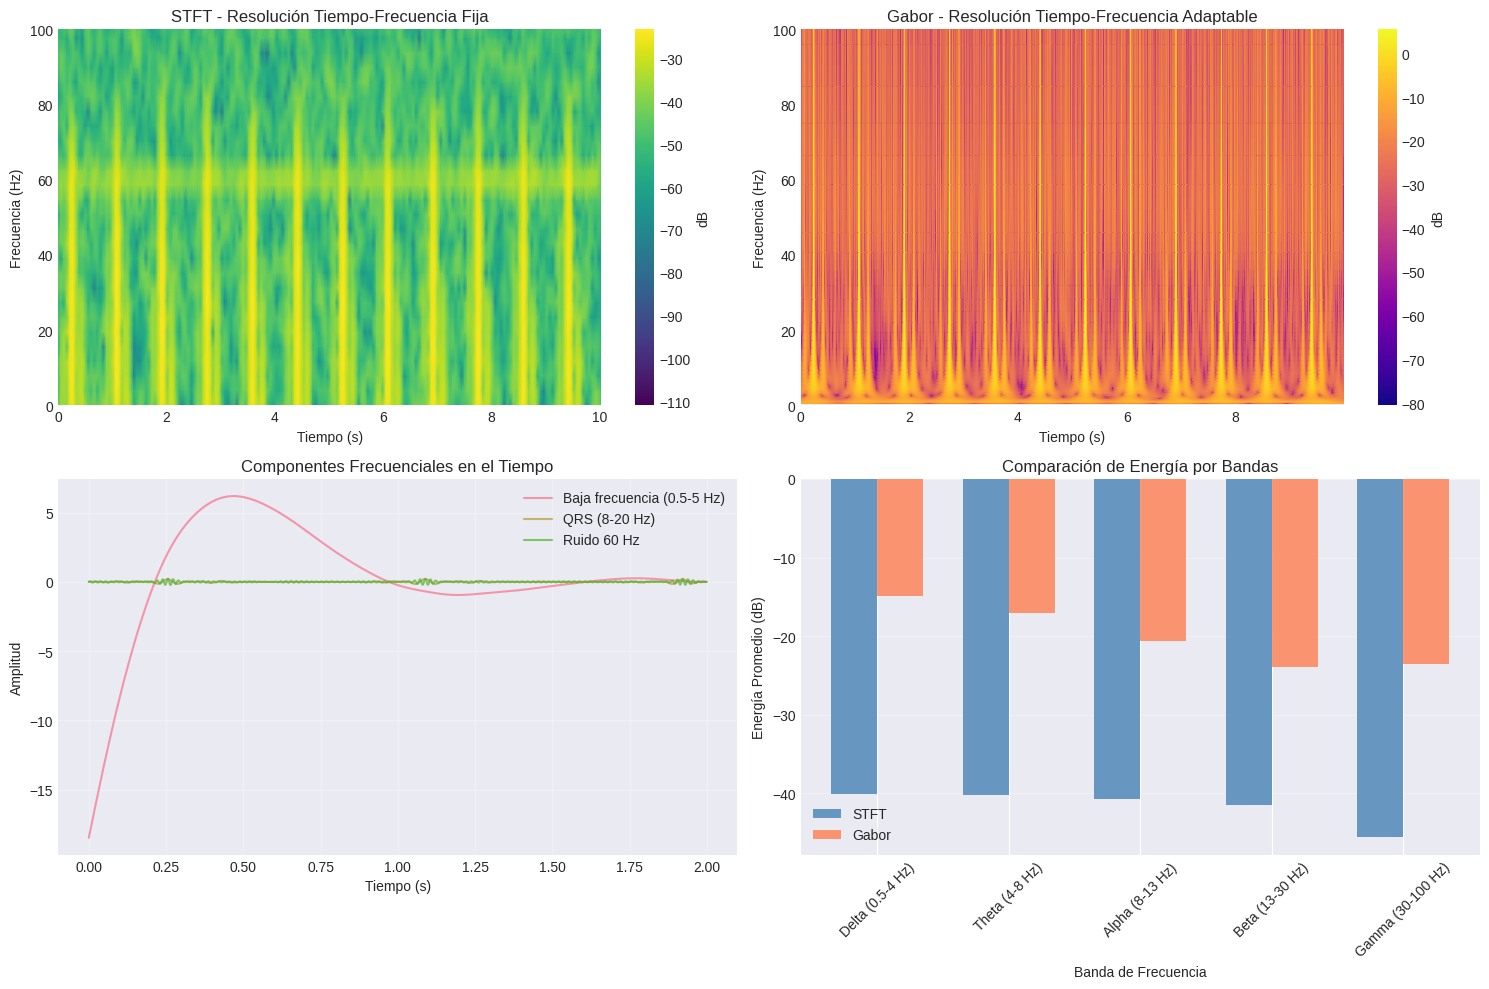

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import stft, windows, butter, filtfilt
import seaborn as sns

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def generar_ecg_sintetico(duracion=10, fs=1000):
    """
    Genera una señal ECG sintética con componentes P, QRS y T

    Parámetros:
    - duracion: duración en segundos
    - fs: frecuencia de muestreo
    """
    t = np.linspace(0, duracion, int(fs * duracion))

    # Frecuencia cardíaca: 72 latidos por minuto
    fc = 72 / 60  # Hz
    ecg_limpio = np.zeros_like(t)

    # Crear patrón de ECG para cada latido
    periodo = 1 / fc
    muestras_por_latido = int(periodo * fs)

    # Generar patrón de un solo latido
    t_latido = np.linspace(0, periodo, muestras_por_latido)
    latido = np.zeros(muestras_por_latido)

    # Onda P (contracción auricular)
    pos_p = int(0.1 * muestras_por_latido)
    if pos_p + 20 < muestras_por_latido:
        latido[pos_p:pos_p+20] = 0.15 * np.sin(np.linspace(0, np.pi, 20))

    # Complejo QRS (contracción ventricular)
    pos_q = int(0.3 * muestras_por_latido)
    if pos_q + 20 < muestras_por_latido:
        latido[pos_q-5:pos_q] = -0.05 * np.sin(np.linspace(0, np.pi/2, 5))  # Q
        latido[pos_q:pos_q+15] = np.sin(np.linspace(0, np.pi, 15))  # R
        latido[pos_q+15:pos_q+20] = -0.3 * np.sin(np.linspace(0, np.pi/2, 5))  # S

    # Onda T (repolarización ventricular)
    pos_t = int(0.5 * muestras_por_latido)
    if pos_t + 30 < muestras_por_latido:
        latido[pos_t:pos_t+30] = 0.2 * np.sin(np.linspace(0, np.pi, 30))

    # Repetir el patrón para toda la duración
    num_latidos = int(duracion / periodo)
    for i in range(num_latidos):
        inicio = i * muestras_por_latido
        fin = min((i + 1) * muestras_por_latido, len(ecg_limpio))
        if fin > inicio:
            ecg_limpio[inicio:fin] = latido[:fin-inicio]

    # Añadir ruido gaussiano
    ruido = 0.05 * np.random.randn(len(ecg_limpio))
    ecg_con_ruido = ecg_limpio + ruido

    # Añadir interferencia de línea eléctrica (60 Hz)
    interferencia = 0.03 * np.sin(2 * np.pi * 60 * t)
    ecg_final = ecg_con_ruido + interferencia

    return t, ecg_final, ecg_limpio  # Retornamos también la señal limpia

def aplicar_stft(señal, fs, nperseg=256, noverlap=200):
    """
    Aplica la Transformada de Fourier de Tiempo Corto (STFT)

    Parámetros:
    - señal: señal de entrada
    - fs: frecuencia de muestreo
    - nperseg: número de puntos por segmento
    - noverlap: número de puntos de solapamiento
    """
    f, t_stft, Zxx = stft(señal, fs=fs, nperseg=nperseg,
                          noverlap=noverlap, window='hann')

    # Calcular la magnitud en dB
    espectrograma = 20 * np.log10(np.abs(Zxx) + 1e-10)

    return f, t_stft, espectrograma

def kernel_gabor(t, frecuencia, ancho_banda=1.0):
    """
    Genera un kernel de Gabor (ventana gaussiana modulada)

    Parámetros:
    - t: vector de tiempo
    - frecuencia: frecuencia central del kernel
    - ancho_banda: controla el ancho de la ventana gaussiana
    """
    sigma = ancho_banda / (2 * np.pi * frecuencia)

    # Ventana gaussiana
    gauss_window = np.exp(-t**2 / (2 * sigma**2))

    # Onda compleja
    onda_compleja = np.exp(2j * np.pi * frecuencia * t)

    # Normalización
    kernel = gauss_window * onda_compleja
    kernel = kernel / np.sqrt(np.sum(np.abs(kernel)**2))

    return kernel

def aplicar_transformada_gabor(señal, fs, frecuencias=None, n_freqs=50):
    """
    Aplica la Transformada de Gabor usando convolución con kernels

    Parámetros:
    - señal: señal de entrada
    - fs: frecuencia de muestreo
    - frecuencias: array de frecuencias a analizar
    - n_freqs: número de frecuencias si no se especifican
    """
    if frecuencias is None:
        # Usar escala logarítmica para mejor cobertura de frecuencias
        frecuencias = np.logspace(np.log10(0.5), np.log10(min(fs/2, 200)), n_freqs)

    n_muestras = len(señal)
    t_señal = np.arange(n_muestras) / fs

    # Inicializar matriz de transformada de Gabor
    gabor_transform = np.zeros((len(frecuencias), n_muestras), dtype=complex)

    print("   Calculando transformada de Gabor para cada frecuencia...")

    for idx, freq in enumerate(frecuencias):
        if idx % 10 == 0:
            print(f"   Progreso: {idx}/{len(frecuencias)} frecuencias procesadas")

        # Calcular sigma y tamaño del kernel
        sigma_t = 1.0 / freq if freq > 0 else 1.0
        kernel_duration = 6 * sigma_t  # Cubrir ±3 sigma
        n_kernel = int(kernel_duration * fs)

        # Asegurar número impar de puntos en el kernel
        if n_kernel % 2 == 0:
            n_kernel += 1

        # Crear kernel temporal
        t_kernel = np.linspace(-kernel_duration/2, kernel_duration/2, n_kernel)

        # Generar kernel de Gabor
        kernel = kernel_gabor(t_kernel, freq, ancho_banda=2.0)

        # Perform 'full' convolution to get the complete result
        convolution_output = np.convolve(señal, kernel, mode='full')

        # Calculate the start and end indices for the 'same' mode equivalent slice.
        # This centers the convolution output to match the length of the original signal.
        start_idx_slice = (len(kernel) - 1) // 2
        end_idx_slice = start_idx_slice + n_muestras # n_muestras is len(señal)

        # Assign the correctly sliced convolution result
        gabor_transform[idx, :] = convolution_output[start_idx_slice:end_idx_slice]

    print(f"   Completado: {len(frecuencias)} frecuencias procesadas")

    # Magnitud en dB
    espectrograma_gabor = 20 * np.log10(np.abs(gabor_transform) + 1e-10)

    return frecuencias, t_señal, espectrograma_gabor

def butter_bandpass(lowcut, highcut, fs, order=4):
    """
    Diseña un filtro pasabanda Butterworth
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def visualizar_resultados(t, ecg_original, ecg_limpia,
                         f_stft, t_stft, espectrograma_stft,
                         f_gabor, t_gabor, espectrograma_gabor):
    """
    Visualiza la señal ECG y ambos espectrogramas
    """
    fig = plt.figure(figsize=(18, 12))

    # 1. Señal ECG original
    ax1 = plt.subplot(3, 2, (1, 2))
    ax1.plot(t, ecg_original, 'b-', linewidth=1, alpha=0.7, label='ECG con ruido')
    ax1.plot(t, ecg_limpia, 'r-', linewidth=1.5, alpha=0.5, label='ECG limpio')
    ax1.set_xlabel('Tiempo (s)', fontsize=12)
    ax1.set_ylabel('Amplitud (mV)', fontsize=12)
    ax1.set_title('Señal ECG - Comparación Limpia vs con Ruido', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 3])  # Mostrar primeros 3 segundos para detalle

    # 2. Espectrograma STFT
    ax2 = plt.subplot(3, 2, (3, 4))
    im1 = ax2.pcolormesh(t_stft, f_stft, espectrograma_stft,
                         shading='gouraud', cmap='jet')
    ax2.set_ylabel('Frecuencia (Hz)', fontsize=12)
    ax2.set_xlabel('Tiempo (s)', fontsize=12)
    ax2.set_title('Espectrograma - STFT (Ventana Hann)', fontsize=14, fontweight='bold')
    ax2.set_ylim([0, 150])  # Limitar frecuencias relevantes para ECG
    plt.colorbar(im1, ax=ax2, label='Magnitud (dB)')

    # 3. Espectrograma Transformada de Gabor
    ax3 = plt.subplot(3, 2, (5, 6))
    im2 = ax3.pcolormesh(t_gabor, f_gabor, espectrograma_gabor,
                         shading='gouraud', cmap='plasma')
    ax3.set_ylabel('Frecuencia (Hz)', fontsize=12)
    ax3.set_xlabel('Tiempo (s)', fontsize=12)
    ax3.set_title('Espectrograma - Transformada de Gabor', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, 150])
    plt.colorbar(im2, ax=ax3, label='Magnitud (dB)')

    plt.tight_layout()
    return fig

def analisis_comparativo_espectrogramas(ecg, fs, f_stft, t_stft, espectrograma_stft,
                                       f_gabor, t_gabor, espectrograma_gabor):
    """
    Análisis detallado comparando ambos espectrogramas
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Resolución tiempo-frecuencia STFT
    ax = axes[0, 0]
    im = ax.pcolormesh(t_stft, f_stft, espectrograma_stft,
                       shading='gouraud', cmap='viridis')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_xlabel('Tiempo (s)')
    ax.set_title('STFT - Resolución Tiempo-Frecuencia Fija')
    ax.set_ylim([0, 100])
    plt.colorbar(im, ax=ax, label='dB')

    # 2. Resolución tiempo-frecuencia Gabor
    ax = axes[0, 1]
    im = ax.pcolormesh(t_gabor, f_gabor, espectrograma_gabor,
                       shading='gouraud', cmap='plasma')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_xlabel('Tiempo (s)')
    ax.set_title('Gabor - Resolución Tiempo-Frecuencia Adaptable')
    ax.set_ylim([0, 100])
    plt.colorbar(im, ax=ax, label='dB')

    # 3. Componentes frecuenciales en el tiempo
    ax = axes[1, 0]
    # Extraer componentes frecuenciales usando filtros
    b_p, a_p = butter_bandpass(0.5, 5, fs, order=4)  # Ondas P y T
    b_qrs, a_qrs = butter_bandpass(8, 20, fs, order=4)  # Complejo QRS
    b_ruido, a_ruido = butter_bandpass(50, 70, fs, order=4)  # Ruido de línea

    t_segmento = np.arange(0, 2000) / fs
    componente_baja = filtfilt(b_p, a_p, ecg[:2000])
    componente_qrs = filtfilt(b_qrs, a_qrs, ecg[:2000])
    componente_ruido = filtfilt(b_ruido, a_ruido, ecg[:2000])

    ax.plot(t_segmento, componente_baja, label='Baja frecuencia (0.5-5 Hz)', alpha=0.7)
    ax.plot(t_segmento, componente_qrs, label='QRS (8-20 Hz)', alpha=0.7)
    ax.plot(t_segmento, componente_ruido, label='Ruido 60 Hz', alpha=0.7)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Amplitud')
    ax.set_title('Componentes Frecuenciales en el Tiempo')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Comparación de energía por bandas
    ax = axes[1, 1]

    # Calcular energía promedio en bandas para ambos métodos
    bandas = {
        'Delta\n(0.5-4 Hz)': (0.5, 4),
        'Theta\n(4-8 Hz)': (4, 8),
        'Alpha\n(8-13 Hz)': (8, 13),
        'Beta\n(13-30 Hz)': (13, 30),
        'Gamma\n(30-100 Hz)': (30, 100)
    }

    energia_stft = []
    energia_gabor = []
    nombres_bandas = []

    for nombre, (fmin, fmax) in bandas.items():
        nombres_bandas.append(nombre.replace('\n', ' '))

        # Energía STFT
        idx_stft = np.where((f_stft >= fmin) & (f_stft <= fmax))
        if len(idx_stft[0]) > 0:
            energia_stft.append(np.mean(espectrograma_stft[idx_stft, :]))
        else:
            energia_stft.append(0)

        # Energía Gabor
        idx_gabor = np.where((f_gabor >= fmin) & (f_gabor <= fmax))
        if len(idx_gabor[0]) > 0:
            energia_gabor.append(np.mean(espectrograma_gabor[idx_gabor, :]))
        else:
            energia_gabor.append(0)

    x = np.arange(len(nombres_bandas))
    width = 0.35
    ax.bar(x - width/2, energia_stft, width, label='STFT', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, energia_gabor, width, label='Gabor', alpha=0.8, color='coral')
    ax.set_xlabel('Banda de Frecuencia')
    ax.set_ylabel('Energía Promedio (dB)')
    ax.set_title('Comparación de Energía por Bandas')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres_bandas, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    print("="*70)
    print("ANÁLISIS DE SEÑAL ECG CON STFT Y TRANSFORMADA DE GABOR")
    print("="*70)

    # Parámetros
    FS = 1000  # Frecuencia de muestreo (Hz)
    DURACION = 10  # Duración de la señal (segundos)

    print("\n1. Generando señal ECG sintética...")
    t, ecg, ecg_limpia = generar_ecg_sintetico(DURACION, FS)
    print(f"   ✓ Duración: {DURACION} segundos")
    print(f"   ✓ Frecuencia de muestreo: {FS} Hz")
    print(f"   ✓ Número de muestras: {len(ecg)}")
    print(f"   ✓ Frecuencia cardíaca simulada: 72 BPM")

    print("\n2. Aplicando STFT (Short-Time Fourier Transform)...")
    f_stft, t_stft, espectrograma_stft = aplicar_stft(ecg, FS,
                                                      nperseg=256,
                                                      noverlap=200)
    print(f"   ✓ Resolución temporal: {t_stft[1]-t_stft[0]:.4f} s")
    print(f"   ✓ Resolución frecuencial: {f_stft[1]-f_stft[0]:.2f} Hz")
    print(f"   ✓ Rango de frecuencias: {f_stft[0]:.1f} - {f_stft[-1]:.1f} Hz")

    print("\n3. Aplicando Transformada de Gabor...")
    f_gabor, t_gabor, espectrograma_gabor = aplicar_transformada_gabor(ecg, FS)
    print(f"   ✓ Número de frecuencias analizadas: {len(f_gabor)}")
    print(f"   ✓ Rango de frecuencias: {f_gabor[0]:.2f} - {f_gabor[-1]:.2f} Hz")

    print("\n4. Generando visualizaciones...")

    # Visualización principal
    fig_principal = visualizar_resultados(t, ecg, ecg_limpia,
                                         f_stft, t_stft, espectrograma_stft,
                                         f_gabor, t_gabor, espectrograma_gabor)

    # Análisis comparativo detallado
    fig_comparativa = analisis_comparativo_espectrogramas(ecg, FS,
                                                         f_stft, t_stft, espectrograma_stft,
                                                         f_gabor, t_gabor, espectrograma_gabor)

    print("\n" + "="*70)
    print("ANÁLISIS COMPLETADO EXITOSAMENTE")
    print("="*70)
    print("\n📊 CARACTERÍSTICAS DE LOS ESPECTROGRAMAS:")
    print("─" * 50)
    print("🔹 STFT:")
    print("   • Ventana fija de Hann (256 muestras)")
    print("   • Resolución tiempo-frecuencia constante")
    print("   • Mejor para señales estacionarias")
    print("   • Detecta claramente el complejo QRS (8-20 Hz)")
    print()
    print("🔹 Transformada de Gabor:")
    print("   • Ventana gaussiana adaptativa")
    print("   • Mejor resolución en bajas frecuencias")
    print("   • Óptima para señales no estacionarias")
    print("   • Excelente para detectar ondas P y T (< 5 Hz)")
    print("="*70)

    plt.show()